# Enhanced sampling: the minimum statistical mechanics you need

This notebook is a **short teaching bridge** from ordinary molecular simulation to umbrella sampling.

The goal is not to teach every enhanced-sampling method. The goal is to highlight the following chain:

> Barriers cause poor sampling → add a bias to visit rare regions → the bias changes the distribution → remove the bias statistically.


## Key six ideas:

1. **Equilibrium averages require representative sampling.** A trajectory confined to one metastable basin cannot determine the equilibrium populations of all basins.
2. **The equilibrium distribution is Boltzmann weighted.** Configurations are sampled with probability proportional to $e^{-\beta U(x)}$.
3. **A simulation average is an ordinary average.** The Boltzmann weighting was already performed by the sampling algorithm.
4. **A collective variable is a low-dimensional description.** Examples include a distance, radius of gyration, coordination number, or torsion angle.
5. **Enhanced sampling changes the sampled distribution on purpose.** In umbrella sampling, this is done by adding a harmonic bias along the collective variable.
6. **The bias must be removed.** Importance sampling gives the reweighting rule; multiple umbrella windows require overlap and a method such as WHAM or MBAR to determine their relative offsets.

### See the 6th i-CoMSE Workshop on Enhanced Sampling for more Material that has details about

detailed-balance derivation, partition-function ratios, Zwanzig free-energy perturbation, MBAR equations, and classification of enhanced-sampling methods.


## Learning objectives

- explain why barriers make ordinary MD or MC inefficient;
- interpret $p(x)\propto e^{-\beta U(x)}$;
- distinguish a microscopic configuration $x$ from a collective variable $s(x)$;
- explain what a bias potential changes;
- derive the sign of the reweighting factor;
- state why umbrella sampling needs several overlapping windows.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(22)

kBT = 1.0
beta = 1.0 / kBT


# 1. Why enhanced sampling is needed

Molecular systems contain fast motions and slow rearrangements. The expensive part is not simply that a slow process takes a long time. The expensive part is that the simulation must resolve fast motions while waiting for rare barrier crossings.

A useful toy picture is a double-well landscape. The two wells are metastable states. The barrier controls how frequently the system moves between them.


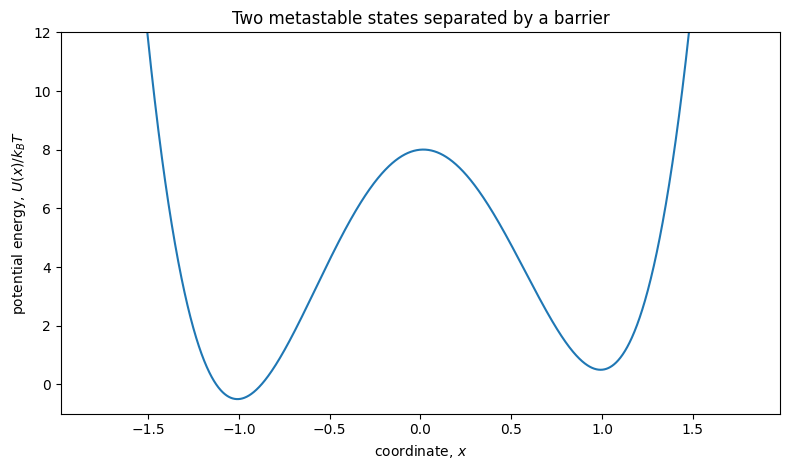

In [3]:
def double_well(x, barrier=8.0, tilt=0.5):
    """A one-dimensional double-well potential in units of kBT."""
    x = np.asarray(x)
    return barrier * (x**2 - 1.0)**2 + tilt * x

x_grid = np.linspace(-1.8, 1.8, 2000)
U_grid = double_well(x_grid)

plt.figure(figsize=(8, 4.8))
plt.plot(x_grid, U_grid)
plt.xlabel(r"coordinate, $x$")
plt.ylabel(r"potential energy, $U(x)/k_BT$")
plt.title("Two metastable states separated by a barrier")
plt.ylim(-1, 12)
plt.tight_layout()
plt.show()


### Central point

The equilibrium average depends on how much equilibrium probability belongs to each basin. A trajectory that never crosses the barrier may look stable and well equilibrated **inside one basin**, while still giving the wrong global equilibrium average.

Repeated transitions are valuable because they provide evidence that the relative populations of the basins are being sampled rather than inherited from the starting structure.


# 2. The probability statement, with minimal notation

For a configuration $x$ with potential energy $U(x)$, the canonical equilibrium probability density is

$$p(x)=\frac{e^{-\beta U(x)}}{Z}.$$

The symbols mean:

- $x$: all coordinates of the system;
- $U(x)$: potential energy of that configuration;
- $\beta=1/(k_BT)$;
- $Z$: the normalization constant, also called the configurational partition function.



$$p(x)\propto e^{-\beta U(x)}.$$

This says that energy differences determine **relative probabilities**. The partition function is needed to make all probabilities sum or integrate to one, but it is not needed when comparing two configurations.


## A three-state example

Suppose three states have energies $0$, $1$, and $3$ in units of $k_BT$. Their unnormalized Boltzmann weights are $1$, $e^{-1}$, and $e^{-3}$.


state   U/kBT   exp(-U/kBT)   probability
  A      0.0        1.0000         0.7054
  B      1.0        0.3679         0.2595
  C      3.0        0.0498         0.0351


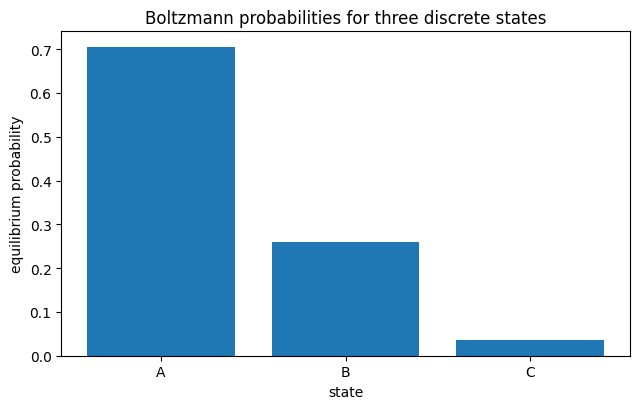

In [4]:
state_names = np.array(["A", "B", "C"])
state_energies = np.array([0.0, 1.0, 3.0])
weights = np.exp(-beta * state_energies)
probabilities = weights / weights.sum()

print("state   U/kBT   exp(-U/kBT)   probability")
for name, energy, weight, probability in zip(
    state_names, state_energies, weights, probabilities
):
    print(f"  {name}     {energy:4.1f}       {weight:7.4f}        {probability:7.4f}")

plt.figure(figsize=(6.5, 4.2))
plt.bar(state_names, probabilities)
plt.xlabel("state")
plt.ylabel("equilibrium probability")
plt.title("Boltzmann probabilities for three discrete states")
plt.tight_layout()
plt.show()


### Important qualification: energy is not the whole free energy story

A single low energy configuration is highly weighted, but a basin can also be important because it contains many configurations. Entropy enters through the number of configurations contributing to a state.

Therefore, avoid saying only “the system goes to the minimum energy.” A better statement is:

> Equilibrium populations reflect both the Boltzmann weight of configurations and how many configurations belong to each state.


# 3. Why trajectory averages do not contain explicit Boltzmann factors

For an observable $A(x)$, the exact equilibrium average is

$$\langle A\rangle=\int A(x)p(x)\,dx.$$

When a simulation has already generated configurations $x_n$ from $p(x)$, the estimator is simply

$$\langle A\rangle\approx\frac{1}{N}\sum_{n=1}^{N}A(x_n).$$

The Boltzmann factors are not missing. They are represented by how frequently different configurations occur in the trajectory.


In [9]:
# Evaluate the double-well potential energy on every point in x_grid.
# barrier=4.0 sets the barrier height, while tilt=0.5 makes one well more favorable.
U_grid_moderate = double_well(x_grid, barrier=4.0, tilt=0.5)

# Convert each potential energy into an unnormalized Boltzmann weight.
# Lower-energy positions receive larger weights.
p_grid = np.exp(-beta * U_grid_moderate)

# Normalize the weights so that their sum is 1.
# After this step, p_grid is a discrete probability distribution over x_grid.
p_grid /= p_grid.sum()

# Randomly select 40,000 indices from x_grid using p_grid as the probability
# of choosing each index. The samples are independent because each draw is
# made directly from the exact equilibrium distribution.
sample_indices = rng.choice(
    len(x_grid),
    size=40_000,
    p=p_grid
)

# Convert the sampled grid indices into the corresponding x values.
x_samples = x_grid[sample_indices]

# Calculate the exact equilibrium mean of x from the complete probability distribution.
# For a discrete distribution, the expectation value is sum_x x * p(x).
exact_mean_x = np.sum(x_grid * p_grid)

# Estimate the equilibrium mean using only the 40,000 sampled configurations.
sample_mean_x = np.mean(x_samples)

# Print the exact mean calculated from the full grid distribution.
print(f"Exact equilibrium mean of x:   {exact_mean_x: .4f}")

# Print the mean estimated from the randomly drawn equilibrium samples.
print(f"Ordinary sample mean of x:    {sample_mean_x: .4f}")

Exact equilibrium mean of x:   -0.4292
Ordinary sample mean of x:    -0.4263


# 4. Collective variables and projected free energy

The full configuration $x$ may contain tens of thousands of coordinates. Enhanced-sampling methods commonly act on a lower-dimensional function of the coordinates,

$$s=s(x),$$

called a **collective variable** or **reaction coordinate**.

Examples include:

- a distance between groups;
- a torsion angle;
- radius of gyration;
- a coordination number;
- the size of a nucleus.

The equilibrium probability along the collective variable is $P(s)$. The corresponding projected free energy is

$$F(s)=-k_BT\ln P(s)+C,$$

where $C$ is an arbitrary additive constant.

In the one-dimensional toy system below, the microscopic coordinate and collective variable are the same: $s=x$.


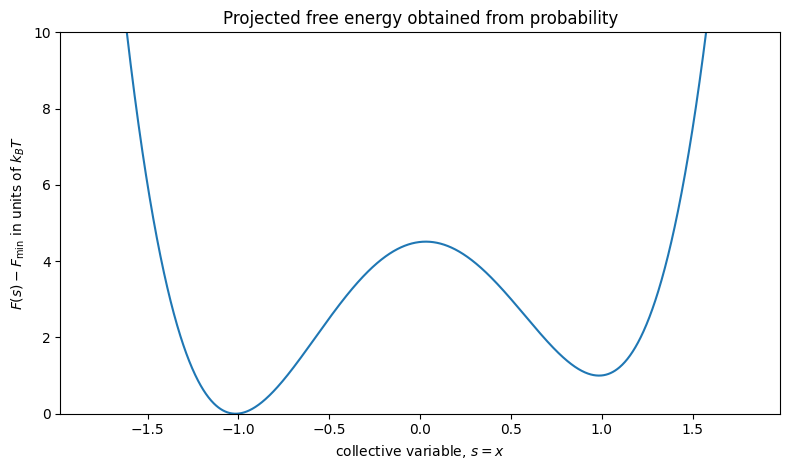

In [6]:
free_energy = -kBT * np.log(p_grid)
free_energy -= free_energy.min()

plt.figure(figsize=(8, 4.8))
plt.plot(x_grid, free_energy)
plt.xlabel(r"collective variable, $s=x$")
plt.ylabel(r"$F(s)-F_{\min}$ in units of $k_BT$")
plt.title("Projected free energy obtained from probability")
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


### Probability and free energy carry the same information

Because $F(s)=-k_BT\ln P(s)+C$:

- high probability corresponds to low free energy;
- low probability corresponds to high free energy;
- a free-energy barrier is a region that is rarely visited at equilibrium.

This is the probability language from the workshop PDF in its most useful form for umbrella sampling.


# 5. What a bias potential does

Enhanced sampling deliberately changes the energy used during the simulation.

Let $V(s)$ be a bias potential. The biased potential energy is

$$U_b(x)=U(x)+V(s(x)).$$

The biased simulation therefore samples

$$p_b(x)\propto e^{-\beta[U(x)+V(s(x))]}.$$

A harmonic umbrella centered at $s_0$ has the form

$$V(s)=\frac{1}{2}k(s-s_0)^2.$$

It encourages the simulation to remain near $s_0$. If $s_0$ is placed in a high-free-energy region, that region becomes much easier to sample.


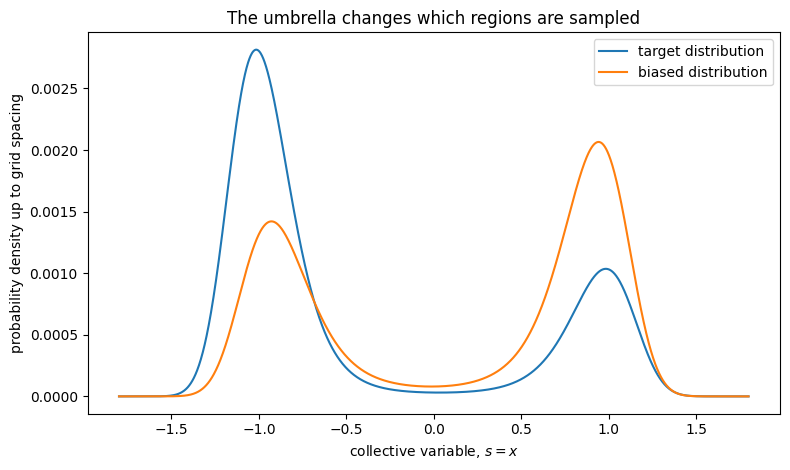

In [7]:
umbrella_center = 0.35
umbrella_k = 2.0
V_grid = 0.5 * umbrella_k * (x_grid - umbrella_center)**2
U_biased = U_grid_moderate + V_grid

p_biased = np.exp(-beta * U_biased)
p_biased /= p_biased.sum()

plt.figure(figsize=(8, 4.8))
plt.plot(x_grid, p_grid, label="target distribution")
plt.plot(x_grid, p_biased, label="biased distribution")
plt.xlabel(r"collective variable, $s=x$")
plt.ylabel("probability density up to grid spacing")
plt.title("The umbrella changes which regions are sampled")
plt.legend()
plt.tight_layout()
plt.show()


# 6. Removing one bias by importance sampling

The target and biased distributions are

$$p(x)=\frac{e^{-\beta U(x)}}{Z},$$

$$p_b(x)=\frac{e^{-\beta[U(x)+V(s(x))]}}{Z_b}.$$

Their ratio is

$$\frac{p(x)}{p_b(x)}=\frac{Z_b}{Z}e^{+\beta V(s(x))}.$$

The unknown constant $Z_b/Z$ cancels when a weighted average is normalized. Therefore,

$$\langle A\rangle=\frac{\sum_{n=1}^{N}A(x_n)e^{\beta V(s_n)}}{\sum_{n=1}^{N}e^{\beta V(s_n)}},$$

where the samples $x_n$ were generated by the biased simulation.

### Why the sign is positive

The biased simulation includes $e^{-\beta V}$. To undo that suppression, reweighting multiplies by $e^{+\beta V}$.


In [10]:
# Draw 50,000 independent samples from the biased probability distribution p_biased.
# The result contains indices identifying positions on x_grid.
biased_indices = rng.choice(
    len(x_grid),
    size=50_000,
    p=p_biased
)

# Convert the sampled grid indices into the corresponding x values.
biased_x = x_grid[biased_indices]

# Evaluate the harmonic umbrella potential for every sampled x value.
# The bias is smallest near umbrella_center and increases quadratically away from it.
biased_V = 0.5 * umbrella_k * (biased_x - umbrella_center)**2

# Calculate the factor needed to remove the effect of the umbrella bias.
# The biased distribution contains exp(-beta*V), so unbiasing uses exp(+beta*V).
reweighting_factors = np.exp(beta * biased_V)

# Calculate the ordinary mean of x in the biased simulation.
# This estimates the mean of the biased distribution, not the original target distribution.
unweighted_mean = np.mean(biased_x)

# Calculate the weighted mean that estimates the mean in the original unbiased ensemble.
# Each sampled value is weighted according to how strongly the bias suppressed it.
reweighted_mean = (
    np.sum(reweighting_factors * biased_x)
    / np.sum(reweighting_factors)
)

# Estimate the effective number of samples contributing after reweighting.
# Highly unequal weights can make the effective sample size much smaller than 50,000.
weighted_ess = (
    reweighting_factors.sum()**2
    / np.sum(reweighting_factors**2)
)

# Print the exact equilibrium mean obtained from the original target distribution.
print(f"Target equilibrium mean:        {exact_mean_x: .4f}")

# Print the ordinary mean measured directly in the biased ensemble.
print(f"Mean in biased simulation:      {unweighted_mean: .4f}")

# Print the estimate of the original equilibrium mean after removing the bias.
print(f"Reweighted target mean:         {reweighted_mean: .4f}")

# Print the weighted effective sample size and compare it with the total sample count.
print(
    f"Weighted effective sample size: "
    f"{weighted_ess: .0f} of {len(biased_x)}"
)

Target equilibrium mean:        -0.4292
Mean in biased simulation:       0.1543
Reweighted target mean:         -0.4314
Weighted effective sample size:  28471 of 50000


## The crucial limitation: overlap

Reweighting is reliable only when the biased simulation visits configurations that matter in the target distribution.

If the weights vary over many orders of magnitude, a tiny number of frames dominate the estimate. The nominal number of frames may be large while the weighted effective sample size is small.

This is why a single narrow umbrella is not enough to reconstruct a broad free-energy profile. Umbrella sampling uses **several overlapping windows**, so that information can be passed across the full collective-variable range.


# 7. Bridge to umbrella sampling

In umbrella window $i$, use

$$V_i(s)=\frac{1}{2}k_i(s-s_i)^2.$$

The window samples the biased distribution

$$P_i^b(s)\propto e^{-\beta[F(s)+V_i(s)]}.$$

Taking the negative logarithm gives

$$-k_BT\ln P_i^b(s)=F(s)+V_i(s)+C_i.$$

Therefore, within one window,

$$F(s)=-k_BT\ln P_i^b(s)-V_i(s)+\text{constant}.$$

The shape can be recovered locally by subtracting the umbrella potential. However, every window has a different unknown constant $C_i$. Overlap between windows allows WHAM or MBAR to determine those relative constants and combine all samples consistently.


# 8. What students should retain

1. A barrier is a sampling problem because it produces long correlation times and missing transitions.
2. Equilibrium probabilities are Boltzmann weighted.
3. $F(s)=-k_BT\ln P(s)+C$ converts a probability profile into a free-energy profile.
4. A bias changes the distribution; it does not merely “speed up time.”
5. Reweighting removes a known bias statistically.
6. Reweighting fails without overlap.
7. Umbrella sampling solves the overlap problem by covering the collective variable with overlapping biased windows.
8. A biased trajectory generally should not be interpreted as physical kinetics.


## Summary

> Ordinary simulations can remain trapped behind free-energy barriers, so the visited configurations may not represent equilibrium. At equilibrium, configurations occur according to the Boltzmann distribution, and a free-energy profile along a collective variable is $-k_BT\ln P(s)$ up to a constant. Enhanced sampling deliberately changes that distribution by adding a bias potential. Because we know the bias, we can statistically remove it by reweighting. Umbrella sampling uses several overlapping harmonic biases, and WHAM or MBAR combines the windows into one unbiased free-energy profile.


## Discussion questions

1. Why can a trajectory look stationary and still give the wrong equilibrium average?
2. Why is the ordinary average correct for an unbiased equilibrium trajectory?
3. What changes when $V(s)$ is added to the Hamiltonian?
4. Why does the reweighting factor contain $e^{+\beta V}$ rather than $e^{-\beta V}$?
5. Why can no reweighting method recover a region that was never sampled?
6. What slow variables might be orthogonal to the chosen collective variable?


## EXTRA NOTES

### Partition function and probability


The full canonical probability density is defined over coordinates and momenta:

$$\rho(\mathbf{q},\mathbf{p})=\frac{1}{Z}e^{-\beta H(\mathbf{q},\mathbf{p})}.$$

For the standard classical Hamiltonian,

$$H(\mathbf{q},\mathbf{p})=K(\mathbf{p})+U(\mathbf{q}).$$

Umbrella sampling usually concerns coordinate dependent observables and collective variables. Integrating the full distribution over momenta gives

$$p(\mathbf{q})=\int \rho(\mathbf{q},\mathbf{p})\,d\mathbf{p}\propto e^{-\beta U(\mathbf{q})}\int e^{-\beta K(\mathbf{p})}\,d\mathbf{p}.$$

The momentum integral is independent of the coordinates and is absorbed into the normalization, leaving

$$p(\mathbf{q})\propto e^{-\beta U(\mathbf{q})}.$$

Thus, $e^{-\beta H}$ is the correct full phase-space distribution, while $e^{-\beta U}$ is the corresponding configurational distribution used in most umbrella sampling derivations. With a coordinate dependent umbrella bias $V(s(\mathbf{q}))$, the configurational distribution becomes

$$p_b(\mathbf{q})\propto e^{-\beta[U(\mathbf{q})+V(s(\mathbf{q}))]}.$$

This assumes the usual separable classical Hamiltonian. More general coordinate systems can introduce additional metric factors when momenta are integrated out.